# Blatt 7, Übung 13

In [ ]:
!pip install -r requirements.txt

## 0. Intro

Im Folgenden wird die Selbstdiffusion innerhalb eines Festelektrolyten modelliert. Die benötigten Dateien liegen in den Ordnern LiPSCl/ und MgSc2Se4/ bereit, es sollen nur die POSCAR-Strukturdateien (jeweils _POSCAR_2x2x2_) genutzt werden. Die anderen Dateien spielen für die Berechnung keine Rolle.
Bei den Strukturdateien handelt es sich um periodische Superzellen der Größe 2x2x2. Als Referenzstruktur der Superzelle dient hier die Einheitszelle, die einer Größe von 1x1x1 entspricht.

Wir verwenden hier ein auf Machine Learning basierendes _Foundation Model_. Bei den Foundation Models handelt es sich um bereits vortrainierte Modelle. Diese können an unterschiedlichen Datenbanken und unterschiedlichen Funktionalen trainiert sein.
Hier verwenden wir das Modell _MACE-MPA-0_. Dieses Modell ist an einem Datensatz von _PBE_-Rechnungen aus einer Datenbank für Materialien trainiert.

Zusätzlich kann mit wenig Erfolg die Diffusion eines Metallatoms auf simplen Mg- oder Li- 001-Metalloberflächen modelliert werden. Die benötigten Dateien liegen in den Ordnern Li/ und Mg/ bereit, es sollen nur die POSCAR-Strukturdateien (jeweils _POSCAR_4x4x3_20vac_) genutzt werden. Die anderen Dateien spielen für die Berechnung keine Rolle.
Bei den Strukturdateien handelt es sich um periodische Superzellen der Größe 4x4x3 mit einem Vacuum von 20 Angstrom oberhalb der Struktur. Als Referenzstruktur der Superzelle dient hier die primitive Zelle, die einer Größe von 1x1x1 entspricht.

Zuerst importieren wir alle nötigen Module:

In [1]:
import os # Macht erstellen von Ordnern und Pfaden einfacher
import copy # Wird gebraucht um die Startstruktur unverändert zu lassen
from ase.visualize import view # import visualisation tools
from ase.io import read, write # Zum Lesen und Schreiben von Strukturdateien
from ase.constraints import ExpCellFilter # Wird für die Strukturoptimierung von periodischen Systemen benötigt
from ase.optimize import BFGS # Solver für die Berechnungen
from ase.md import Langevin  # NVT-Implementation für eine MD
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution # Wird fpr die Initialisierung der Geschwindigkeiten benötigt
from ase import units # Macht das Handling und die Umrechnung von Einheiten einfacher
from ase.io.trajectory import Trajectory # Wird benötigt um die Trajektorie zu speichern und an das Atoms object anzuhängen
from ase.io.vasp import write_vasp_xdatcar # Um Trajektorien zu XDATCAR zu schreiben
from mace.calculators import MACECalculator # Ein Rechner zur Berechnung
from mace.calculators import mace_mp # Das Foundation Model
import numpy as np
import ipywidgets
#import pandas as pd # vielleicht um Werte zu speicher

/home/sutz/miniconda3/envs/ModSimUebung/lib/python3.13/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


Die zur Verfügung gestellten Strukturen wurden von Hand erstellt. Diese sollte erst relaxiert werden. Entsprechend gehen wir folgendermaßen vor:
1. Importieren der Struktur.
2. Relaxieren der Struktur.
3. Durchführung der MD-Rechnung (soll über mehrere Temperaturen geloopt werden).
4. Berechnung und Visualisierung der Diffusionskoeffizienten.

## 1. Importieren

Um eine Struktur einzulesen muss keine spezifische Funktion geschrieben werden. Wir können eine Standardfunktion von _ASE_ nutzen.

Wir definieren zuerst die Pfade zu unseren Strukturen und lesen die Dateien anschließend mit der Funktion _read_, die wir oberhalb aus _ase.io_ importier haben ein. POSCAR ist eine Strukturdatei die von der Software _VASP_ verwendet wird, manchmal wird der Dateityp deshalb auch als _vasp_ bezeichnet. Entsprechend müssen wir diesen Dateitypen angeben. Dafür benutzen wir das keyword _format_:

In [2]:
path_to_Li = 'Li/POSCAR_4x4x3_20vac'
path_to_Mg = 'Mg/POSCAR_4x4x3_20vac'
path_to_MgBulk = 'Mg/POSCAR_3x3x3Bulk'
path_to_LiPSCl = 'LiPSCl/POSCAR_2x2x2'
path_to_MgScSe =  'MgSc2Se4/POSCAR_2x2x2'
path_to_BB = 'BerlinerBlau/POSCAR'

structure_BB = read(path_to_BB,format='vasp')
view(structure_BB, viewer='ngl')

_ASE_ importiert die Dateien als _Atoms_-Objekt, das diverse Attribute besitzt, die verändert werden können. Für den weiteren Verlauf sind tiefere Kenntnisse über Objekte aber nicht vonnöten, eine Einführung wird es an dieser Stelle deshalb nicht geben. Wichtig ist für uns nur, dass einem _Atoms_-Objekt eine Berechnungsgrundlage angehängt werden kann. Diese wird als _calc_ bezeichnet und im nächsten Schritt genutzt.

### Zusätzliche Strukturen: Metalloberflächen, Li-, Mg-Festelektrolyte

In [ ]:
structure_Li = read(path_to_Li,format='vasp')
structure_Mg = read(path_to_Mg,format='vasp')
structure_MgBulk = read(path_to_MgBulk,format='vasp')

structure_LiPSCl = read(path_to_LiPSCl,format='vasp')
structure_MgScSe = read(path_to_MgScSe,format='vasp')

In [ ]:
view(structure_LiPSCl , viewer='ngl')

In [ ]:
view(structure_MgScSe , viewer='ngl')

## 2. Relaxation

 Wir definieren zuerst eine einen Rechner für _calc_ aus einem _Mace Foundation Model_:

In [3]:
mace_calc = mace_mp('medium-mpa-0',default_type='float32')

Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /home/sutz/.cache/mace/macempa0mediummodel
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/home/sutz/miniconda3/envs/ModSimUebung/lib/python3.13/site-packages/mace/calculators/mace.py:143: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using head default out of ['default']
Default dtype float32 does not match model dtype float64, converting models to float32.


Auf welchen Grundlagen genau dieses Modell basiert ist für uns nicht weiter wichtig, könnte aber in der Dokumentation nachgelesen werden. Wichtig ist das Funktional des Datensatzes, welches hier _PBE_ ist. _PBE_ ist ein relativ beliebtes Funktional und wurde bestimmt in der Vorlesung besprochen.

Unsere Strukturdateien sind bereits eingelesen, nun müssen wir noch eine Geometrieoptimierung durchführen um eine sinnvolle Startstruktur zu erhalten. Da es sich um eine Oberfläche handelt wollen wir nicht die komplette Struktur optimieren, sondern nur die Positionen. Die Gitterkonstanten sollen unverändert erhalten bleiben, was den Rechenaufwand erheblich senken kann.

Für die Strukturoptimierung lässt sich eine Funktion definieren. Diese Funktion soll eine Struktur in Form eines _Atoms_-Objekts nutzen, dem Objekt einen Rechner anhängen, die Gitterparameter fixieren und anschließend die Struktur optimieren. Normalerweise müssen bestimmte Bedingungen oder Konvergenzkriterien angegeben werden, ab der die Strukturoptimierung abgebrochen/beender wird. In unserem Fall geben wir vor, dass alle auftretenden Kräfte unterhalb von 0.01 eV/A liegen müssen. Als Argumente, bzw. Input, benötigen wir also folgendes:
1. Struktur als _Atoms_-Objekt (_structure_ in der Funktion),
2. Rechner als _calc_-Objekt (_calc_ in der Funktion),
3. Eine Funktionalität, mithilfe der Gitterkonstanten fixiert werden können (_fix_cell_ in der Funktion, optional),
4. Eine Funktionalität zur Optimierung der Struktur,
5. Eine Abbruchbedingung (_f_ in der Funktion).

Wir können die Funktion wie folgt definieren:

In [4]:
def relaxation_mace(structure, calc, fix_cell = True, f = 0.01):
    '''
    Parameters
    ----------
    structure : ATOMS object
        Struktur die für die Optimierung genutzt werden soll.
    calc : CALCULATOR object
        Rechner der im weiteren Laufe zur Simulation genutzt werden soll.
    fix_cell : BOOL, optional
        Beschreibt, ob die Gitterkonstanten fix oder veränderlich sind. The default is True.
    f : FLOAT, optional
        Konvergenzkriterium zum Beenden der Optimierung. The default is 0.01.

    Returns
    -------
    structure_data : DICTIONARY
        Beinhaltet die optimierte Struktur als ATOMS object und separat die berechnete Energie.
    '''
    # define calculator
    structure.calc = calc # Hier wird ein zusätzlicher Rechner definiert, auf Grundlage dessen alle weiteren Rechnungen durchgeführt werden
    
    # check for constraints and run
    if fix_cell == True: # kleine Anpassung für periodische Systeme, da wird ein ExpCellFilter gebraucht
        cell_filter = ExpCellFilter(structure)
        opt = BFGS(cell_filter) # BFGS ist ein Solver
    else:    
        opt = BFGS(structure)
        opt.run(fmax=f)  # Optimize until forces < 0.01 eV/Å   
        pass
    
    print("Optimising geometry...")
    opt.run(fmax=f)  # Optimise until forces < 0.01 eV/Å
    # set up dict with relaxed structure
    structure_data={'relaxed_structure':structure,'total_energy':structure.get_total_energy()}
    return structure_data

Die Funktion gibt uns ein _dictionary_ _structure_data_ aus. Ein für uns neuer Datentyp in Python. Es folgt eine kurze Erklärung, prinzipiell kann diese Zelle aber übersprungen werden.

Im Unterschied zu einer _list_ wird in einem _dictionary_ auf den Inhalt nicht über einen Index zugegriffen. Die Zuordnung erfolgt über sogenannte _key:value_-Paare, initiiert wird dieser Datentyp über geschweifte Klammern. Dabei wird jedem _key_ ein _value_ zugewiesen in der Form _dict = {key1:value1 , key2:value2}.
In unserem Fall sind die Keys _'relaxed_structure'_ und _'total_energy'. Der Zugriff erfolgt über folgenden Syntax: dict[key]. In unserer Funktion kann über _structure_data['relaxed_structure']_ auf die optimierte Struktur zugegriffen werden.



Wir können die Struktur direkt optimieren und das Ergebnis direkt im nächsten Schritt nutzen.

In [5]:
BB_relaxed = relaxation_mace(structure_BB, mace_calc, fix_cell = False, f = 0.01)
view(BB_relaxed['relaxed_structure'], viewer='ngl')

      Step     Time          Energy          fmax
BFGS:    0 21:01:39     -492.385895        0.662645
BFGS:    1 21:01:39     -492.456970        0.882844
BFGS:    2 21:01:40     -492.669373        0.638793
BFGS:    3 21:01:40     -492.752167        0.227971
BFGS:    4 21:01:40     -492.745422        0.372200
BFGS:    5 21:01:40     -492.756714        0.013999
BFGS:    6 21:01:40     -492.756927        0.011803
BFGS:    7 21:01:40     -492.757080        0.015734
BFGS:    8 21:01:40     -492.757172        0.013439
BFGS:    9 21:01:40     -492.757141        0.015066
BFGS:   10 21:01:40     -492.757172        0.000155
Optimising geometry...


### Zusätzliche Strukturen

In [ ]:
MgScSe_relaxed = relaxation_mace(structure_MgScSe, mace_calc, fix_cell = False, f = 0.01)
view(MgScSe_relaxed['relaxed_structure'], viewer='ngl')

In [ ]:
LiPSCl_relaxed = relaxation_mace(structure_LiPSCl, mace_calc, fix_cell = False, f = 0.01)
view(LiPSCl_relaxed['relaxed_structure'], viewer='ngl')

Die Oberflächen sind unterhalb, aber nicht weiter von Belang.

In [ ]:
Mg_relaxed=relaxation_mace(structure_Mg, mace_calc, fix_cell = True, f = 0.01)
view(Mg_relaxed['relaxed_structure'], viewer='ngl')

In [ ]:
Li_relaxed=relaxation_mace(structure_Li, mace_calc, fix_cell = True, f = 0.01)
view(Li_relaxed['relaxed_structure'], viewer='ngl')

## 3. MD-Simulation

Als nächstes wollen wir unsere Funktion _MD_mace_ zur Durchführung einer MD-Simulation definieren. Die Anfangsstructur bekommen wir bereits aus _relaxation_mace_, das _calc_-Objekt wurde dort auch bereits angehängt. Wir müssen es nicht erneut definieren.

Wir nutzen die Zeit um kurz die Funktionalität zu reflektieren, bevor wir weitermachen:
- Welcher Input muss für eine MD vorgegeben werden? Das muss unserer Funktion als Argumente übergeben werden.
    1. Struktur _structure_,
    2. (Start)temperatur in K _T_start_,
    3. Zeitschritt in fs _t_step_,
    4. Gesamter Zeitintervall in Anzahl an Zeitschritten _n_steps_,
    5. Thermostat, wird hier aber festgelegt als Langevin,
    6. Friction Coefficient für Langevin in 1/fs _friction_coefficient_. Statt der Anzahl an Zeitschritten könnten wir auch einen Zeitwert in fs vorgeben und innerhalb der Funktion runden,
    7. Der Ordner in dem die Trajektorien ausgegeben werden _traj_out_.
- Welchen Output wünschen wir uns?
    1. Die Trajectorie _trajectory_.
 
In vielen Fällen sind neben der eigentlichen Trajektorie zusätzlich Energien und Kräfte von Interesse, der Einfachheit halber betrachten wir diese hier aber nicht.

In [6]:
def MD_mace(structure, traj_out = 'output', T_start = 300.0, t_step = 3, n_steps = 1000, friction_coefficient = 1E-3):
    '''    
    Parameters
    ----------
    structure : ATOMS
        DESCRIPTION.
    traj_out : STRING, optional
        DESCRIPTION. The default is 'output'.
    T_start : FLOAT, optional
        DESCRIPTION. The default is 300.0.
    t_step : FLOAT, optional
        DESCRIPTION. The default is 3.
    n_steps : INT, optional
        DESCRIPTION. The default is 1000.
    friction_coefficient : FLOAT, optional
        DESCRIPTION. The default is 1E-3.

    Returns
    -------
    structure : ATOMS
        DESCRIPTION.
    '''
    
    # Geschwindigkeiten initialisieren
    MaxwellBoltzmannDistribution(structure, temperature_K=T_start)

    # Langevin-Setup für ein NVT-Ensemble
    dyn = Langevin(structure, timestep = t_step * units.fs, temperature_K = T_start, friction = friction_coefficient / units.fs)
    
    # Wir können einen Ordner anlegen, in dem die Trajektorien gespeichert werden
    try:
        os.makedirs(traj_out)
        print(f"Nested directories '{traj_out}' created successfully.")
    except FileExistsError:
        print(f"One or more directories in '{traj_out}' already exist.")
    except PermissionError:
        print(f"Permission denied: Unable to create '{traj_out}'.")
    except Exception as e:
        print(f"An error occurred: {e}")
    # Definition einer Trajektorie, die angehängt werden kann
    traj = Trajectory(f'{traj_out}/{int(T_start)}K.traj', 'w', structure)
    dyn.attach(traj.write, interval=1)  # Writes to the trajectory file every 10 steps

    # Start der MD Simulation
    dyn.run(n_steps)
    traj.close()
    
    # Write als XDATCAR zusätzlich
    saved_traj = Trajectory(f'{traj_out}/{int(T_start)}K.traj')
    xdatcar_file = f'{traj_out}/XDATCAR_{int(T_start)}K'
    write_vasp_xdatcar(xdatcar_file, saved_traj, label=None)

    return structure

Nun sind wir bereit um aus den optimierten Strukturen eine MD-Simulation zu berechnen. Um ein Arrheniusverhalten simulieren zu können, brauchen wir einen größeren Temperaturbereich. Da wir uns nur für die Diffusion im Festkörper interessieren, sollten wir alle Temperaturen unterhalb des Schmelzpunkts des jeweiligen Metalls wählen. Dieser liegt für beide Materialien oberhalb von 1000°C. Wir können also auf bis zu circa 1300 K gehen. Wir fangen zuerst mit Lithium an:

In [24]:
traj_dir = 'BB_Trajectories'
T_list = [1100.0,1400.0,1700.0]

for Temp in T_list:
    print(f'Temperatur ist {Temp}')
    structure_tempo = copy.deepcopy(BB_relaxed['relaxed_structure'])
    MD_mace(structure_tempo, traj_out = traj_dir, T_start = Temp, t_step = 2.5, n_steps = 5000, friction_coefficient = 1E-3)
    pass

frames = read(f'{traj_dir}/{int(Temp)}K.traj', index=':')
view(frames,viewer='ngl')

Temperatur ist 1100.0
One or more directories in 'BB_Trajectories' already exist.
Temperatur ist 1400.0
One or more directories in 'BB_Trajectories' already exist.
Temperatur ist 1700.0
One or more directories in 'BB_Trajectories' already exist.


### Zusätzliche Strukturen

In [ ]:
T_list = [300.0,500.0,700.0,900.0,1100.0,1300.0]
traj_dir = 'LiPSCl_Trajectories'
for Temp in T_list:
    print(f'Temperatur ist {Temp}')
    structure_tempo = copy.deepcopy(LiPSCl_relaxed['relaxed_structure'])
    MD_mace(structure_tempo, traj_out = traj_dir, T_start = Temp, t_step = 2.5, n_steps = 1000, friction_coefficient = 1E-3)
    pass

Die letzte MD-Simulation wollen wir uns beispielhaft anschauen:

In [ ]:
frames = read(f'{traj_dir}/{int(Temp)}K.traj', index=':')
view(frames,viewer='ngl')

Gleiches können wir für MgSc2Se4 machen:

In [ ]:
T_list = [800.0,1000.0,1200.0,1400.0,1600.0,1800.0,2000.0]
traj_dir = 'MgSc2Se4_Trajectories'
for Temp in T_list:
    print(f'Temperatur ist {Temp}')
    structure_tempo = copy.deepcopy(MgScSe_relaxed['relaxed_structure'])
    MD_mace(structure_tempo, traj_out = traj_dir, T_start = Temp, t_step = 2.5, n_steps = 1000, friction_coefficient = 1E-3)
    pass

frames = read(f'{traj_dir}/{int(Temp)}K.traj', index=':')
view(frames,viewer='ngl')

### Diffusion auf Metalloberflächen

Beides könnten wir auch für die Metalloberflächen machen. Da die Schmelzpunkte hier jedoch für Li bei 180°C und für Mg bei 650°C liegen, können wir nur einen sehr kleinen Temperaturbereich simulieren. Erfahrungsgemäß kann es hierbai zu Schwierigkeiten kommen. Wir schauen uns die Simulation deshalb nicht näher an. Unterhalb ist sie dennoch zu sehen:

In [ ]:
T_Li = [200.0,250.0,300.0,350.0,400.0,450.0]
Li_traj_dir = 'Li_Trajectories'
for Temp in T_Li:
    print(f'Temperatur ist {Temp}')
    structure_tempo = copy.deepcopy(Li_relaxed['relaxed_structure'])
    MD_mace(structure_tempo, traj_out = Li_traj_dir, T_start = Temp, t_step = 3, n_steps = 100, friction_coefficient = 1E-3)
    pass

# Wir sehen uns beispielhaft die letzte Trajektorie an
frames = read(f'Li_Trajectories/{int(Temp)}K.traj', index=':')
view(frames,viewer='ngl')

Identisch ist der Vorgang bei Magnesium:

In [ ]:
view(Li_relaxed['relaxed_structure'],viewer='ngl')

In [ ]:
T_Mg = [200.0,250.0,300.0,350.0,400.0,450.0,500.0,550.0,600.0]
Mg_traj_dir = 'Mg_Trajectories'
for Temp in T_Mg:
    print(f'Temperatur ist {Temp}')
    structure_tempo = copy.deepcopy(Mg_relaxed['relaxed_structure'])
    MD_mace(structure_tempo, traj_out = Mg_traj_dir, T_start = Temp, t_step = 3, n_steps = 100, friction_coefficient = 1E-3)
    pass
    
# Wir sehen uns beispielhaft die letzte Trajektorie an
frames = read(f'Mg_Trajectories/{int(Temp)}K.traj', index=':')
view(frames,viewer='ngl')

Wir können uns zusätzlich noch den Schmelzvorgang von Lithium anschauen, einfach weil wir es können:

In [ ]:
Temp = 1000.0
Li_traj_dir = 'Li_Trajectories'
print(f'Temperatur ist {Temp}')
structure_tempo = copy.deepcopy(Li_relaxed['relaxed_structure'])
MD_mace(structure_tempo, traj_out = Li_traj_dir, T_start = Temp, t_step = 3, n_steps = 5000, friction_coefficient = 1E-3)

# Wir sehen uns beispielhaft die letzte Trajektorie an
frames = read(f'Li_Trajectories/{int(Temp)}K.traj', index=':')
view(frames,viewer='ngl')

In [ ]:
frames = read(f'Li_Trajectories/{int(Temp)}K.traj', index=':')
view(frames,viewer='ngl')

## 4. Berechnung und Plotting des Arrheniusgraphen

Als erstes importieren wir irgendeinen Bums (der Rest sollte da sein):

In [8]:
import matplotlib.pyplot as plt
from kinisi.analyze import DiffusionAnalyzer
from kinisi.arrhenius import StandardArrhenius
import warnings
import os.path
import corner
warnings.filterwarnings("ignore", category=UserWarning)

Dann führen wir ein unglaublich kompliziertes Skript aus, das ich mal für XDATCARs geschrieben habe, aber hier auf die Trajektorien aus ASE angepasst ist. Wir definieren das hier mal als Funktion, weil der Rest eigentlich nicht mal mehr mich interessiert:

In [27]:
def Arrhenius_Plot(MD_target='.',plot_title='Standardtitel',specie='Mg',time_step=2.5,time_skip=1000.0,step_skip=1):
        
    #MD_target='MgSc2Se4_Trajectories'
    #plot_title='MgSc2Se4 Bulk Diffusion'
    
    # define folder that contains trajectory files and create a list of them
    trajectories_list = [f'{MD_target}/{el}' for el in os.listdir(MD_target) if el.endswith('.traj')]
    
    np.random.seed(42)
    rng = np.random.RandomState(42) # is not used right now because of reproducibility
    
    p_params = {'specie': specie,
              #'specie_indices': [97],
              'time_step': time_step,
              'step_skip': step_skip,
              'progress': False,
              #'max_dt': 3000,
              #'min_dt': 100,
              #'n_steps': 200
              }
    u_params = {'dimension':'xyz',
                'progress': False}
    d_params={'progress': False}
    
    #time_skip=1000.0
    
    temps=np.array([]) # empty array, temps will be appended in the loop
    D=[] # append diffusion coeffs
    analyzers=[] #append analyzers
    
    for traj_file in trajectories_list:
        traj_name = os.path.basename(traj_file) # get the base name of the trajectory file
        
        # Extract temperature from filename - you'll need to adjust this based on your naming convention
        # Assuming format like "simulation_temp_500K.traj" or similar
        # Please modify this line based on your actual file naming pattern:
        temp = float(traj_name.split('_')[-1].replace('K.traj', '').replace('.traj', ''))
        
        temps = np.append(temps, temp)
        
        # Read ASE trajectory
        trajectory = read(traj_file, ':')
        
        # Create DiffusionAnalyzer from ASE trajectory
        diff = DiffusionAnalyzer.from_ase(trajectory, parser_params=p_params, uncertainty_params=u_params)
        diff.diffusion(time_skip, diffusion_params={'random_state': None, 'progress': False})
        D.append(diff.D)
        analyzers.append(diff)
    
        # Create subplot figure for this temperature
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        fig.suptitle(f'{traj_name} - Temperature: {temp} K', fontsize=14)
        
        # Plot 1: MSD vs time (linear scale)
        axes[0, 0].errorbar(diff.dt, diff.msd, diff.msd_std)
        axes[0, 0].set_ylabel('MSD/Å$^2$')
        axes[0, 0].set_xlabel(r'$\Delta t$/ps')
        axes[0, 0].set_title('MSD vs Time (Linear)')
        axes[0, 0].grid(True, alpha=0.3)
    
        # Plot 2: MSD vs time (log scale)
        axes[0, 1].errorbar(diff.dt, diff.msd, diff.msd_std)
        axes[0, 1].axvline(time_skip, color='g', label=f'time_skip={time_skip}')
        axes[0, 1].set_ylabel('MSD/Å$^2$')
        axes[0, 1].set_xlabel(r'$\Delta t$/ps')
        axes[0, 1].set_yscale('log')
        axes[0, 1].set_xscale('log')
        axes[0, 1].set_title('MSD vs Time (Log-Log)')
        axes[0, 1].grid(True, alpha=0.3)
        axes[0, 1].legend()
    
        # Plot 3: MSD with credible intervals
        credible_intervals = [[15, 85], [2.5, 97.5], [0.15, 99.85]]
        alpha = [0.05, 0.1, 0.2]
        
        axes[1, 0].plot(diff.dt, diff.msd, 'k-', linewidth=2)
        for i, ci in enumerate(credible_intervals):
            axes[1, 0].fill_between(diff.dt,
                             *np.percentile(diff.distribution, ci, axis=1),
                             alpha=alpha[i],
                             color='#0173B2',
                             lw=0)
        axes[1, 0].set_ylabel('MSD/Å$^2$')
        axes[1, 0].set_xlabel(r'$\Delta t$/ps')
        axes[1, 0].set_title('MSD with Credible Intervals')
        axes[1, 0].grid(True, alpha=0.3)
    
        # Plot 4: Histogram of diffusion coefficients
        axes[1, 1].hist(diff.D.samples, density=True, bins=30, alpha=0.7)
        axes[1, 1].axvline(diff.D.n, c='k', linewidth=2, label=f'Mean D = {diff.D.n:.2e}')
        axes[1, 1].set_xlabel('$D$/cm$^2$s$^{-1}$')
        axes[1, 1].set_ylabel('$p(D$/cm$^2$s$^{-1})$')
        axes[1, 1].set_title('Diffusion Coefficient Distribution')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
    
        plt.tight_layout()
        #plt.show()
    
        print(f"{temp} K; D = {diff.D.n:.2e} ± {diff.D.ci()}")
        print(f"Intercept = {diff.intercept.n:.2e} ± {diff.intercept.ci()}")
        
        # Corner plot for this temperature
        corner.corner(diff._diff.flatchain, labels=['$D$/cm$^2$s$^{-1}$', 'intercept/Å$^2$'])
        #plt.show()
    
    #%%
    # arrhenius parameters
    
    s = StandardArrhenius(temps, D, bounds=((1E-3,1),(1e-20,1E-5)))
    s.max_likelihood('mini')
    s.mcmc()
    
    #%% visualise probability of parameter distribution
    plt.close('all')
    unit_cms=' cm\u00b2 s\u207B\u00b9'
    fig=corner.corner(s.flatchain, labels=['$E_a$/eV', '$A$/cm$^2$s$^{-1}$'])
    fig.set_size_inches(8,8) # dont know how to change the size otherwise
    corner.overplot_lines(fig, s.variable_medians, color="orange")
    corner.overplot_points(fig, s.variable_medians[None], marker="s", color="orange")
    corner.overplot_lines(fig, s.variable_modes, color="green")
    corner.overplot_points(fig, s.variable_modes[None], marker="s", color="green")
    
    # place a text box in upper left in axes coords
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    inplot_text="Median Ea = "+np.format_float_scientific(np.round(s.variable_medians[0],3))+" eV\nMedian A = "+np.format_float_scientific(s.variable_medians[1],precision=2)+unit_cms
    inplot_text2="\nMode Ea = "+np.format_float_scientific(np.round(s.variable_modes[0],3))+" eV\nMode A = "+np.format_float_scientific(s.variable_modes[1],precision=2)+unit_cms
    fig.text(0.6,0.75, inplot_text+inplot_text2,fontsize=14,verticalalignment='center',ha='left',bbox=props)
    fig.savefig(MD_target+'/ArrheniusParamsDistribution_kinisi'+plot_title+'.png',dpi=1000)
    
    # print arrhenius parameters information and save to file
    print("Modes are green, medians are orange")
    print("Modes are Ea / eV: "+np.format_float_scientific(s.variable_modes[0])+", A / cm2 s-1: "+np.format_float_scientific(s.variable_modes[1],precision=2))
    print("Medians are Ea / eV: "+np.format_float_scientific(s.variable_medians[0])+", A / cm2 s-1: "+np.format_float_scientific(s.variable_medians[1],precision=2))
    # diffusion coefficient at 300K
    D300K=np.format_float_scientific(s.variable_medians[1]*np.exp(-s.variable_medians[0]/300/1E-5/8.62),precision=2)
    print("Using median values, D / cm2 s-1 at 300K is: "+D300K)
    print("Median Absolute Deviation of A / cm2 s-1 is: "+np.format_float_scientific(np.median(np.absolute(s.variables[0] - np.median(s.variables[0]))),precision=2))
    print("Median Absolute Deviation of Ea / eV is: "+np.format_float_scientific(np.median(np.absolute(s.variables[1] - np.median(s.variables[1]))),precision=2))
    with open(MD_target+'/MD_Parameters_kinisi.txt', 'w') as f:
        f.write("Modes are green, medians are orange.\n")
        f.write("Modes are Ea / eV: "+np.format_float_scientific(s.variable_modes[0])+", A / cm2 s-1: "+np.format_float_scientific(s.variable_modes[1])+'\n')
        f.write("Medians are Ea / eV: "+np.format_float_scientific(s.variable_medians[0])+", A / cm2 s-1: "+np.format_float_scientific(s.variable_medians[1])+'\n')
        f.write("Median Absolute Deviation of A / cm2 s-1 is: "+np.format_float_scientific(np.median(np.absolute(s.variables[0] - np.median(s.variables[0]))))+'\n')
        f.write("Median Absolute Deviation of Ea / eV is: "+np.format_float_scientific(np.median(np.absolute(s.variables[1] - np.median(s.variables[1]))))+'\n')

        f.write("\nUsing median values, D / cm2 s-1 at 300K is: "+D300K)
        pass
    f.close()
    
    # plot arrhenius function
    fig2,ax2=plt.subplots(figsize=(10,8))
    
    # plot data points
    plt.errorbar(1000/s.x, s.y.n, s.y.ci(), marker='o', ls='', color='k', zorder=10)
    
    Tx = np.linspace(300, 2500, 200) # temps
    Dy = s.variable_medians[1]*np.exp(-s.variable_medians[0]/Tx/1E-5/8.62) # Ds
    Dy2=s.variable_medians[0]/8.62/1E5*1000/Tx
    plt.plot(1000/Tx, Dy,color='red')
    plt.yscale('log')
    plt.xlabel('$1000T^{-1}$/K$^{-1}$')
    plt.ylabel('$D$/cm$^2$s$^{-1}$')
    plt.title(plot_title)
    
    # place a text box in upper left in axes coords
    ax2.text(0.75,0.95, inplot_text+'\nD$_{300K}$ = '+D300K+unit_cms, transform=ax2.transAxes, fontsize=18,
            verticalalignment='top',ha='center',bbox=props)
    plt.savefig(MD_target+'/ArrheniusPlot_kinisi'+plot_title+'.png',dpi=1000)
    plt.show()

Wir schauen uns nun den linearisierten Arrheniusplot von Berliner Blau an:

1400.0 K; D = 4.36e-08 ± [2.12125259e-08 6.50086094e-08]
Intercept = 3.47e+00 ± [3.151784   3.77964306]
1700.0 K; D = 4.62e-08 ± [1.82586274e-08 7.28668469e-08]
Intercept = 3.42e+00 ± [2.90646004 3.92208309]
800.0 K; D = 3.04e-08 ± [1.30159762e-08 4.73734178e-08]
Intercept = 2.05e+00 ± [1.6597581  2.44617966]
1100.0 K; D = 4.79e-08 ± [2.75650526e-08 6.80078284e-08]
Intercept = 2.14e+00 ± [1.57087534 2.70856564]


  0%|          | 0/1000 [00:00<?, ?it/s]/home/sutz/miniconda3/envs/ModSimUebung/lib/python3.13/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 1000/1000 [00:11<00:00, 89.06it/s]


Modes are green, medians are orange
Modes are Ea / eV: 6.845552280169843e-02, A / cm2 s-1: 7.62e-08
Medians are Ea / eV: 8.798293604532971e-02, A / cm2 s-1: 9.69e-08
Using median values, D / cm2 s-1 at 300K is: 3.23e-09
Median Absolute Deviation of A / cm2 s-1 is: 3.24e-02
Median Absolute Deviation of Ea / eV is: 2.83e-08


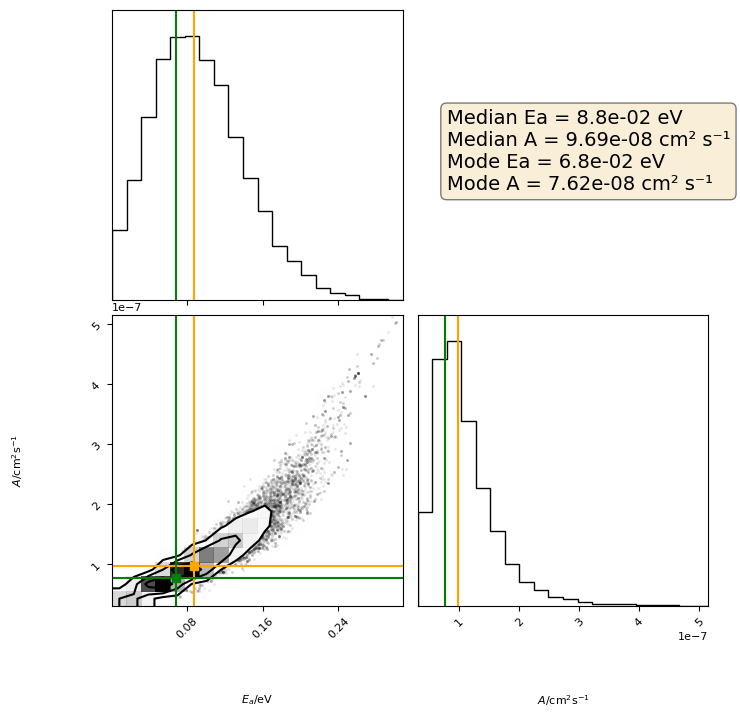

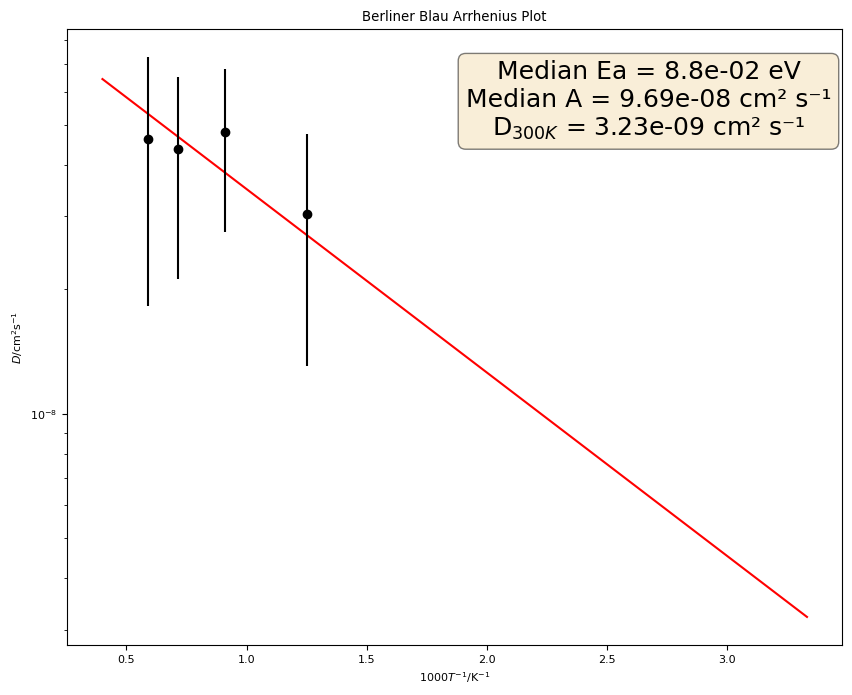

In [28]:
Arrhenius_Plot(MD_target='BB_Trajectories',plot_title='Berliner Blau Arrhenius Plot',specie='Na',time_skip=500)

### Zusätzliche Strukturen

Wir schauen uns nun den linearisierten Arrheniusplot von MgSc2Se4 an:

In [ ]:
Arrhenius_Plot(MD_target='LiPSCl_Trajectories',plot_title='LiPSCl Arrhenius Plot',specie='Li')

Das können wir auch für MgSc2Se4 machen und es vergleichen:

In [ ]:
Arrhenius_Plot(MD_target='MgSc2Se4_Trajectories',plot_title='MgSc2Se Arrhenius Plot',specie='Mg')